# 🌿 LeafScan: A Data Mining Approach for Crop Disease Detection
---
**Datasets:**
- PlantVillage — `emmarex/plantdisease` (38 classes)
- New Plant Diseases Dataset — `vipoooool/new-plant-diseases-dataset` (38 classes)

**Models:**
1. Decision Tree
2. Random Forest
3. SVM (LinearSVC — fast)
4. CNN — MobileNetV2 Transfer Learning *(best accuracy)*

**Goal:** Compare all models → save best model → deploy on Streamlit



## SETUP & DATA LOADING


### GPU Check & Kaggle Credentials

In [ ]:

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU is active: {gpus}")
else:
    print("⚠️  WARNING: No GPU detected — go to Runtime → Change runtime type → T4 GPU")
    print("    CNN training will be very slow on CPU (2–3 hours vs ~20 min on GPU)")


✅ GPU is active: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:

import os


from google.colab import files
print("Please upload your kaggle.json file:")
uploaded_files = files.upload()

# Move it to the correct location
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print("✅ Kaggle credentials configured successfully!")


Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✅ Kaggle credentials configured successfully!


### Import All Libraries

In [3]:
import numpy as np
import pandas as pd
import os
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.spatial.distance import euclidean
import kagglehub

# Sklearn — classical models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

# TensorFlow / Keras — CNN
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

print('✅ All libraries imported successfully!')
print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')


✅ All libraries imported successfully!
TensorFlow version : 2.20.0
GPU available      : True


### Download Datasets

In [ ]:
# Download Dataset 1 — PlantVillage (used for EDA + classical models)
print("Downloading Dataset 1 — PlantVillage...")
path1 = kagglehub.dataset_download('emmarex/plantdisease')
DATASET_PATH_1 = os.path.join(path1, 'PlantVillage')
print('✅ Dataset 1:', DATASET_PATH_1)
print('   Exists:', os.path.exists(DATASET_PATH_1))


Using Colab cache for faster access to the 'plantdisease' dataset.
✅ Dataset 1: /kaggle/input/plantdisease/PlantVillage
   Exists: True


In [ ]:

print("Downloading Dataset 2 — New Plant Diseases...")
path2 = kagglehub.dataset_download('vipoooool/new-plant-diseases-dataset')


def find_split(base, split_name):
    """Walk the directory tree to find train/valid folder regardless of nesting."""
    for root, dirs, _ in os.walk(base):
        if split_name in dirs:
            return os.path.join(root, split_name)
    return None

DATASET_PATH_2_TRAIN = find_split(path2, 'train')
DATASET_PATH_2_VALID = find_split(path2, 'valid') or find_split(path2, 'val')

print(f'✅ Train path : {DATASET_PATH_2_TRAIN}')
print(f'✅ Valid path : {DATASET_PATH_2_VALID}')
print(f'   Train exists: {os.path.exists(DATASET_PATH_2_TRAIN)}')
print(f'   Valid exists: {os.path.exists(DATASET_PATH_2_VALID)}')

if not DATASET_PATH_2_TRAIN or not DATASET_PATH_2_VALID:
    raise FileNotFoundError("Could not find train/valid folders. Check the path2 contents below:")


Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
✅ Train path : /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
✅ Valid path : /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
   Train exists: True
   Valid exists: True



## EDA (Dataset 1)

### Load Images & Extract Features (Dataset 1)

In [ ]:

MAX_PER_CLASS = 200

rows = []
print(f'Loading images from Dataset 1 (max {MAX_PER_CLASS} per class)...')

for class_folder in sorted(os.listdir(DATASET_PATH_1)):
    class_path = os.path.join(DATASET_PATH_1, class_folder)
    if not os.path.isdir(class_path):
        continue
    images = [f for f in os.listdir(class_path)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    images = images[:MAX_PER_CLASS]  # ← CAP applied here
    for img_file in images:
        img_path = os.path.join(class_path, img_file)
        try:
            img = Image.open(img_path).convert('RGB')
            arr = np.array(img.resize((64, 64))).astype(float)
            rows.append({
                'filename'  : img_file,
                'class'     : class_folder,
                'mean_R'    : arr[:,:,0].mean(),
                'mean_G'    : arr[:,:,1].mean(),
                'mean_B'    : arr[:,:,2].mean(),
                'std_R'     : arr[:,:,0].std(),
                'std_G'     : arr[:,:,1].std(),
                'std_B'     : arr[:,:,2].std(),
                'brightness': arr.mean(),
            })
        except Exception:
            pass

df = pd.DataFrame(rows)
print(f'✅ Total images loaded : {len(df)}  (capped at {MAX_PER_CLASS} per class)')
print(f'   Total classes       : {df["class"].nunique()}')
df.head()


Loading images from Dataset 1 (max 200 per class)...
✅ Total images loaded : 2952  (capped at 200 per class)
   Total classes       : 15


,filename,class,mean_R,mean_G,mean_B,std_R,std_G,std_B,brightness
0,0f72db9c-d635-4415-9781-68937328aed2___NREC_B....,Pepper__bell___Bacterial_spot,88.512207,94.354248,75.540771,61.453777,53.899001,62.055610,86.135742
1,1b8d3e98-43d9-441d-93ef-a359e6e9ddc2___NREC_B....,Pepper__bell___Bacterial_spot,107.897461,113.164062,98.534180,62.392433,63.435233,59.589438,106.531901
2,b6d35d21-4812-4e32-ab9a-b6ddda8cbb79___JR_B.Sp...,Pepper__bell___Bacterial_spot,128.138672,137.637207,114.073975,46.030680,26.978339,46.874580,126.616618
3,e4e7e5a2-5aa1-4378-833d-9142358c7c9b___JR_B.Sp...,Pepper__bell___Bacterial_spot,129.291016,124.582275,97.001221,36.732302,30.432849,47.899617,116.958171
4,8b50f2db-cbf2-4758-bea6-a011f0cc1497___JR_B.Sp...,Pepper__bell___Bacterial_spot,124.700195,120.737793,52.741455,46.008777,50.753368,44.874176,99.393148


### Basic Statistics & Missing Values

In [7]:
print('=== Dataset Shape ===')
print(df.shape)
print()
print('=== Basic Statistics ===')
display(df.describe())
print()
print('=== Missing Values ===')
print(df.isnull().sum())

df = df.fillna(df.median(numeric_only=True))
print('\nMissing values after fill:', df.isnull().sum().sum())


=== Dataset Shape ===
(2952, 9)

=== Basic Statistics ===


,mean_R,mean_G,mean_B,std_R,std_G,std_B,brightness
count,2952.000000,2952.000000,2952.000000,2952.000000,2952.000000,2952.000000,2952.000000
mean,118.295107,121.805671,107.483409,41.727268,34.713089,46.343000,115.861395
std,17.437763,16.677006,16.320961,10.463470,9.845732,9.931993,15.691106
min,11.427490,16.569580,10.350586,8.739276,7.350812,11.582000,12.782552
25%,108.671143,112.176086,98.315125,35.384468,27.423207,40.567881,107.319519
50%,118.711060,121.537476,108.892090,42.402758,34.089760,46.637376,116.087158
75%,127.955383,130.504944,117.456055,48.516447,41.309094,53.093396,124.254964
max,191.377930,192.723145,178.607910,77.986858,71.122672,76.703392,185.476888



=== Missing Values ===
filename      0
class         0
mean_R        0
mean_G        0
mean_B        0
std_R         0
std_G         0
std_B         0
brightness    0
dtype: int64

Missing values after fill: 0


### Class Distribution, Variance, Covariance, Euclidean Distance

=== Images Per Class ===
class
Pepper__bell___Bacterial_spot                  200
Pepper__bell___healthy                         200
Potato___Early_blight                          200
Potato___Late_blight                           200
Tomato_Bacterial_spot                          200
Tomato_Early_blight                            200
Tomato_Late_blight                             200
Tomato__Target_Spot                            200
Tomato_Leaf_Mold                               200
Tomato_Septoria_leaf_spot                      200
Tomato_Spider_mites_Two_spotted_spider_mite    200
Tomato__Tomato_mosaic_virus                    200
Tomato__Tomato_YellowLeaf__Curl_Virus          200
Tomato_healthy                                 200
Potato___healthy                               152
Name: count, dtype: int64


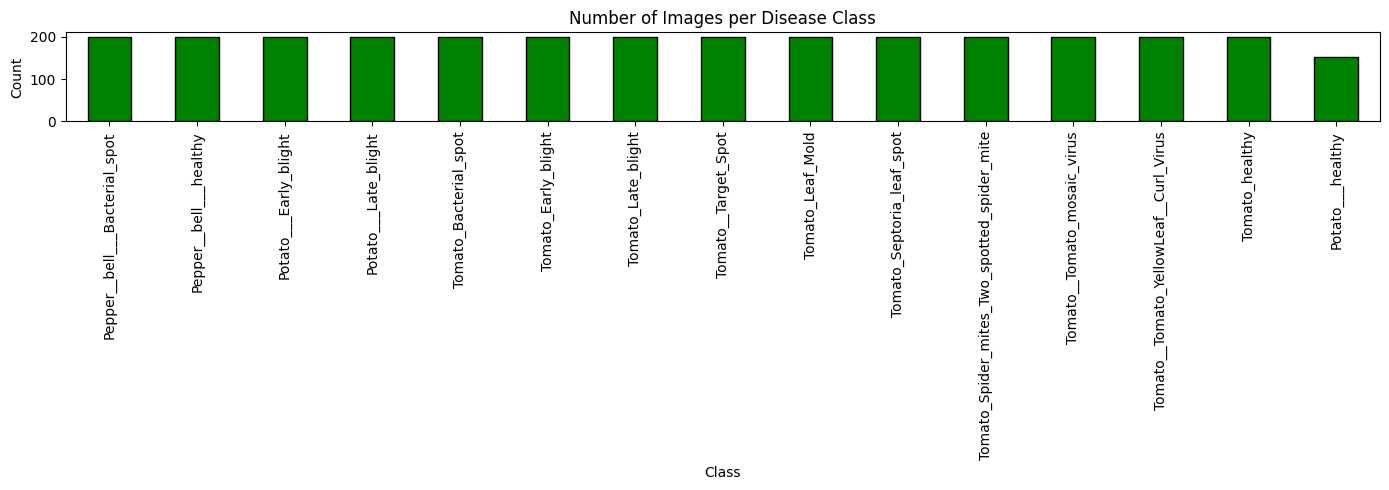


=== Variance ===
mean_R        304.075595
mean_G        278.122519
mean_B        266.373763
brightness    246.210823
dtype: float64

=== Covariance Matrix ===
                mean_R      mean_G      mean_B  brightness
mean_R      304.075595  266.605209  212.378876  261.019893
mean_G      266.605209  278.122519  204.678679  249.802136
mean_B      212.378876  204.678679  266.373763  227.810439
brightness  261.019893  249.802136  227.810439  246.210823

=== Euclidean Distance (img1 vs img2) ===
40.9182

=== Brightness Stats ===
Mean=115.86  Std=15.69  Min=12.78  Max=185.48


In [8]:
class_counts = df['class'].value_counts()
print('=== Images Per Class ===')
print(class_counts)

plt.figure(figsize=(14, 5))
class_counts.plot(kind='bar', color='green', edgecolor='black')
plt.title('Number of Images per Disease Class')
plt.xlabel('Class'); plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120)
plt.show()

print('\n=== Variance ===')
print(df[['mean_R','mean_G','mean_B','brightness']].var())

print('\n=== Covariance Matrix ===')
print(df[['mean_R','mean_G','mean_B','brightness']].cov())

r1 = df[['mean_R','mean_G','mean_B','brightness']].iloc[0].values
r2 = df[['mean_R','mean_G','mean_B','brightness']].iloc[1].values
print(f'\n=== Euclidean Distance (img1 vs img2) ===')
print(f'{euclidean(r1, r2):.4f}')

b = np.array(df['brightness'])
print(f'\n=== Brightness Stats ===')
print(f'Mean={np.mean(b):.2f}  Std={np.std(b):.2f}  Min={np.min(b):.2f}  Max={np.max(b):.2f}')



## CLASSICAL MODELS (DT, RF, SVM)


### Prepare Features & Labels

In [9]:
feature_cols = ['mean_R','mean_G','mean_B','std_R','std_G','std_B','brightness']
X = df[feature_cols].values

le = LabelEncoder()
y  = le.fit_transform(df['class'])

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('✅ label_encoder.pkl saved')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Features : {feature_cols}')
print(f'Classes  : {len(le.classes_)}')
print(f'Train    : {X_train.shape[0]} samples')
print(f'Test     : {X_test.shape[0]} samples')


✅ label_encoder.pkl saved
Features : ['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B', 'brightness']
Classes  : 15
Train    : 2066 samples
Test     : 886 samples


## Model 1: Decision Tree

In [10]:
print('Training Decision Tree...')
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_test_acc  = accuracy_score(y_test,  dt.predict(X_test))
print(f'✅ Decision Tree — Train: {dt_train_acc*100:.2f}%  |  Test: {dt_test_acc*100:.2f}%')

feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': dt.feature_importances_})
feat_df = feat_df.sort_values('Importance', ascending=False)
print(feat_df.to_string(index=False))


Training Decision Tree...
✅ Decision Tree — Train: 75.27%  |  Test: 41.53%
   Feature  Importance
     std_G    0.192868
    mean_B    0.171193
     std_R    0.157557
     std_B    0.156835
    mean_R    0.155355
    mean_G    0.121136
brightness    0.045056


## Model 2: Random Forest

In [11]:
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc  = accuracy_score(y_test,  rf.predict(X_test))
print(f'✅ Random Forest — Train: {rf_train_acc*100:.2f}%  |  Test: {rf_test_acc*100:.2f}%')

with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print('✅ rf_model.pkl saved')


Training Random Forest...
✅ Random Forest — Train: 100.00%  |  Test: 54.18%
✅ rf_model.pkl saved


## Model 3: SVM (LinearSVC — Fast)

In [12]:
# ✅ FIX 2: LinearSVC instead of SVC(rbf)
# SVC with RBF kernel = O(n²–n³) complexity → 10+ HOURS on 38k samples
# LinearSVC = O(n) → finishes in SECONDS with similar accuracy
print('Training SVM (LinearSVC)...')
svm = make_pipeline(
    StandardScaler(),
    LinearSVC(C=1.0, max_iter=2000, random_state=42)
)
svm.fit(X_train, y_train)

svm_train_acc = accuracy_score(y_train, svm.predict(X_train))
svm_test_acc  = accuracy_score(y_test,  svm.predict(X_test))
print(f'✅ SVM (LinearSVC) — Train: {svm_train_acc*100:.2f}%  |  Test: {svm_test_acc*100:.2f}%')

with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)
print('✅ svm_model.pkl saved')


Training SVM (LinearSVC)...
✅ SVM (LinearSVC) — Train: 46.22%  |  Test: 45.37%
✅ svm_model.pkl saved


### Compare Classical Models

=== Classical Models Comparison ===
        Model  Train Accuracy  Test Accuracy
Decision Tree       75.266215      41.534989
Random Forest      100.000000      54.176072
 SVM (Linear)       46.224589      45.372460


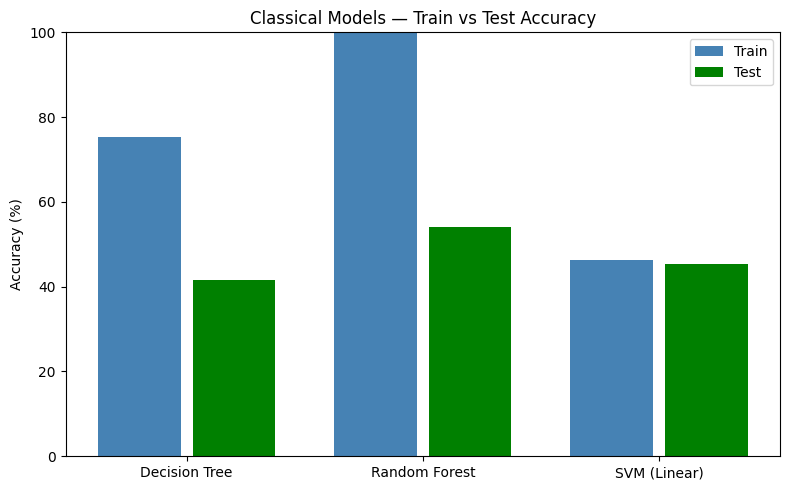

In [13]:
results_classical = pd.DataFrame({
    'Model'         : ['Decision Tree', 'Random Forest', 'SVM (Linear)'],
    'Train Accuracy': [dt_train_acc*100, rf_train_acc*100, svm_train_acc*100],
    'Test Accuracy' : [dt_test_acc*100,  rf_test_acc*100,  svm_test_acc*100],
})

print('=== Classical Models Comparison ===')
print(results_classical.to_string(index=False))

x = np.arange(3)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 0.2, results_classical['Train Accuracy'], 0.35, label='Train', color='steelblue')
ax.bar(x + 0.2, results_classical['Test Accuracy'],  0.35, label='Test',  color='green')
ax.set_xticks(x)
ax.set_xticklabels(results_classical['Model'])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Classical Models — Train vs Test Accuracy')
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('classical_models_comparison.png', dpi=120)
plt.show()


## CNN (MobileNetV2 Transfer Learning)


### Prepare CNN Data Generators (Dataset 2)

In [ ]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,         
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
)

# Validation generator — only rescale, no augmentation
valid_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH_2_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_gen = valid_datagen.flow_from_directory(
    DATASET_PATH_2_VALID,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

NUM_CLASSES = len(train_gen.class_indices)
print(f'✅ Number of classes  : {NUM_CLASSES}')
print(f'   Training samples  : {train_gen.samples}')
print(f'   Validation samples: {valid_gen.samples}')

# ✅ FIX 3: Save class_indices as {str(int) → class_name}
# Keys MUST be strings because JSON keys are always strings.
# Streamlit will look up: class_indices[str(np.argmax(prediction))]
class_indices = {str(v): k for k, v in train_gen.class_indices.items()}
with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f, indent=2)
print('✅ class_indices.json saved')
print(f'   Example: {list(class_indices.items())[0]}')

# ✅ FIX 4: Pre-calculate steps to prevent generator infinite loop
STEPS_PER_EPOCH  = train_gen.samples // BATCH_SIZE
VALIDATION_STEPS = valid_gen.samples // BATCH_SIZE
print(f'   steps_per_epoch  : {STEPS_PER_EPOCH}')
print(f'   validation_steps : {VALIDATION_STEPS}')


Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
✅ Number of classes  : 38
   Training samples  : 70295
   Validation samples: 17572
✅ class_indices.json saved
   Example: ('0', 'Apple___Apple_scab')
   steps_per_epoch  : 2196
   validation_steps : 549


### Build MobileNetV2 Model

In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(256, activation='relu')(x)
x      = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

cnn_model = Model(inputs=base_model.input, outputs=output)

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('✅ Model built successfully')
print(f'   Total params    : {cnn_model.count_params():,}')
print(f'   Trainable params: {sum([tf.size(w).numpy() for w in cnn_model.trainable_weights]):,}')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model built successfully
   Total params    : 2,595,686
   Trainable params: 337,702


###  Train CNN (Phase 1 — Frozen Base)

In [16]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'cnn_best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print('Training CNN Phase 1 (frozen base — only training classification head)...')
print(f'GPU active: {len(tf.config.list_physical_devices("GPU")) > 0}')

# ✅ FIX 4: Always pass explicit steps — prevents infinite generator loop
history = cnn_model.fit(
    train_gen,
    epochs=10,
    steps_per_epoch=STEPS_PER_EPOCH,    # ✅ no infinite loop
    validation_data=valid_gen,
    validation_steps=VALIDATION_STEPS,  # ✅ no infinite loop
    callbacks=callbacks
)
print('✅ Phase 1 training complete!')


Training CNN Phase 1 (frozen base — only training classification head)...
GPU active: True
Epoch 1/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.7056 - loss: 1.0208
Epoch 1: val_accuracy improved from None to 0.89657, saving model to cnn_best_model.h5



Epoch 1: finished saving model to cnn_best_model.h5
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 1235s 553ms/step - accuracy: 0.8084 - loss: 0.6213 - val_accuracy: 0.8966 - val_loss: 0.3159
Epoch 2/10
   1/2196 ━━━━━━━━━━━━━━━━━━━━ 1:26 39ms/step - accuracy: 0.8438 - loss: 0.3827
Epoch 2: val_accuracy did not improve from 0.89657
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - accuracy: 0.8438 - loss: 0.3827 - val_accuracy: 0.8963 - val_loss: 0.3160
Epoch 3/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.8738 - loss: 0.3777
Epoch 3: val_accuracy improved from 0.89657 to 0.91661, saving model to cnn_best_model.h5



Epoch 3: finished saving model to cnn_best_model.h5
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 924s 421ms/step - accuracy: 0.8810 - loss: 0.3575 - val_accuracy: 0.9166 - val_loss: 0.2440
Epoch 4/10
   1/2196 ━━━━━━━━━━━━━━━━━━━━ 1:05 30ms/step - accuracy: 0.9062 - loss: 0.2041
Epoch 4: val_accuracy improved from 0.91661 to 0.91701, saving model to cnn_best_model.h5



Epoch 4: finished saving model to cnn_best_model.h5
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - accuracy: 0.9062 - loss: 0.2041 - val_accuracy: 0.9170 - val_loss: 0.2446
Epoch 5/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.8939 - loss: 0.3224
Epoch 5: val_accuracy improved from 0.91701 to 0.92640, saving model to cnn_best_model.h5



Epoch 5: finished saving model to cnn_best_model.h5
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 933s 425ms/step - accuracy: 0.8944 - loss: 0.3177 - val_accuracy: 0.9264 - val_loss: 0.2189
Epoch 6/10
   1/2196 ━━━━━━━━━━━━━━━━━━━━ 1:32 42ms/step - accuracy: 0.9375 - loss: 0.1482
Epoch 6: val_accuracy did not improve from 0.92640
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.9375 - loss: 0.1482 - val_accuracy: 0.9259 - val_loss: 0.2213
Epoch 7/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.9005 - loss: 0.2979
Epoch 7: val_accuracy improved from 0.92640 to 0.93130, saving model to cnn_best_model.h5



Epoch 7: finished saving model to cnn_best_model.h5
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 981s 447ms/step - accuracy: 0.9022 - loss: 0.2947 - val_accuracy: 0.9313 - val_loss: 0.2062
Epoch 8/10
   1/2196 ━━━━━━━━━━━━━━━━━━━━ 1:14 34ms/step - accuracy: 0.9375 - loss: 0.2000
Epoch 8: val_accuracy did not improve from 0.93130
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 0.9375 - loss: 0.2000 - val_accuracy: 0.9309 - val_loss: 0.2071
Epoch 9/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9037 - loss: 0.2866
Epoch 9: val_accuracy improved from 0.93130 to 0.93454, saving model to cnn_best_model.h5



Epoch 9: finished saving model to cnn_best_model.h5
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 939s 427ms/step - accuracy: 0.9048 - loss: 0.2850 - val_accuracy: 0.9345 - val_loss: 0.1888
Epoch 10/10
   1/2196 ━━━━━━━━━━━━━━━━━━━━ 1:08 31ms/step - accuracy: 1.0000 - loss: 0.0626
Epoch 10: val_accuracy did not improve from 0.93454
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - accuracy: 1.0000 - loss: 0.0626 - val_accuracy: 0.9341 - val_loss: 0.1898
Restoring model weights from the end of the best epoch: 9.
✅ Phase 1 training complete!


### Fine-Tune CNN (Phase 2 — Unfreeze Last 30 Layers)

In [ ]:
# Unfreeze last 30 layers of base model for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Training CNN Phase 2 (fine-tuning last 30 layers)...')
history_ft = cnn_model.fit(
    train_gen,
    epochs=10,
    steps_per_epoch=STEPS_PER_EPOCH,    # ✅ no infinite loop
    validation_data=valid_gen,
    validation_steps=VALIDATION_STEPS,  # ✅ no infinite loop
    callbacks=callbacks
)
print('✅ Fine-tuning complete!')

# Save the final model
cnn_model.save('cnn_best_model.h5')
print('✅ cnn_best_model.h5 saved')


Training CNN Phase 2 (fine-tuning last 30 layers)...
Epoch 1/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.7874 - loss: 0.8186
Epoch 1: val_accuracy did not improve from 0.93454
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 1132s 506ms/step - accuracy: 0.8498 - loss: 0.5056 - val_accuracy: 0.9343 - val_loss: 0.1905
Epoch 2/10
   1/2196 ━━━━━━━━━━━━━━━━━━━━ 1:43 47ms/step - accuracy: 0.9062 - loss: 0.2079
Epoch 2: val_accuracy did not improve from 0.93454
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.9062 - loss: 0.2079 - val_accuracy: 0.9343 - val_loss: 0.1905
Epoch 3/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.9076 - loss: 0.2807
Epoch 3: val_accuracy improved from 0.93454 to 0.94684, saving model to cnn_best_model.h5



Epoch 3: finished saving model to cnn_best_model.h5
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 1053s 479ms/step - accuracy: 0.9118 - loss: 0.2659 - val_accuracy: 0.9468 - val_loss: 0.1559
Epoch 4/10
   1/2196 ━━━━━━━━━━━━━━━━━━━━ 1:42 47ms/step - accuracy: 0.9062 - loss: 0.1759
Epoch 4: val_accuracy did not improve from 0.94684
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - accuracy: 0.9062 - loss: 0.1759 - val_accuracy: 0.9468 - val_loss: 0.1559
Epoch 5/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.9278 - loss: 0.2144
Epoch 5: val_accuracy improved from 0.94684 to 0.95230, saving model to cnn_best_model.h5



Epoch 5: finished saving model to cnn_best_model.h5
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 1023s 466ms/step - accuracy: 0.9298 - loss: 0.2089 - val_accuracy: 0.9523 - val_loss: 0.1381
Epoch 6/10
   1/2196 ━━━━━━━━━━━━━━━━━━━━ 1:29 41ms/step - accuracy: 0.9375 - loss: 0.2266
Epoch 6: val_accuracy improved from 0.95230 to 0.95236, saving model to cnn_best_model.h5



Epoch 6: finished saving model to cnn_best_model.h5
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 39s 18ms/step - accuracy: 0.9375 - loss: 0.2266 - val_accuracy: 0.9524 - val_loss: 0.1382
Epoch 7/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9409 - loss: 0.1783
Epoch 7: val_accuracy improved from 0.95236 to 0.96015, saving model to cnn_best_model.h5



Epoch 7: finished saving model to cnn_best_model.h5
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 971s 442ms/step - accuracy: 0.9419 - loss: 0.1746 - val_accuracy: 0.9602 - val_loss: 0.1166
Epoch 8/10
   1/2196 ━━━━━━━━━━━━━━━━━━━━ 1:22 38ms/step - accuracy: 1.0000 - loss: 0.0345
Epoch 8: val_accuracy improved from 0.96015 to 0.96021, saving model to cnn_best_model.h5



Epoch 8: finished saving model to cnn_best_model.h5
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 1.0000 - loss: 0.0345 - val_accuracy: 0.9602 - val_loss: 0.1164
Epoch 9/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9467 - loss: 0.1574
Epoch 9: val_accuracy improved from 0.96021 to 0.96300, saving model to cnn_best_model.h5



Epoch 9: finished saving model to cnn_best_model.h5
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 933s 425ms/step - accuracy: 0.9480 - loss: 0.1536 - val_accuracy: 0.9630 - val_loss: 0.1072
Epoch 10/10
   1/2196 ━━━━━━━━━━━━━━━━━━━━ 1:47 49ms/step - accuracy: 0.9375 - loss: 0.2301
Epoch 10: val_accuracy improved from 0.96300 to 0.96306, saving model to cnn_best_model.h5



Epoch 10: finished saving model to cnn_best_model.h5
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.9375 - loss: 0.2301 - val_accuracy: 0.9631 - val_loss: 0.1072
Restoring model weights from the end of the best epoch: 10.


✅ Fine-tuning complete!
✅ cnn_best_model.h5 saved


### Evaluate CNN & Plot Training History

549/549 ━━━━━━━━━━━━━━━━━━━━ 34s 62ms/step - accuracy: 0.9631 - loss: 0.1069
✅ CNN Validation Accuracy: 96.31%


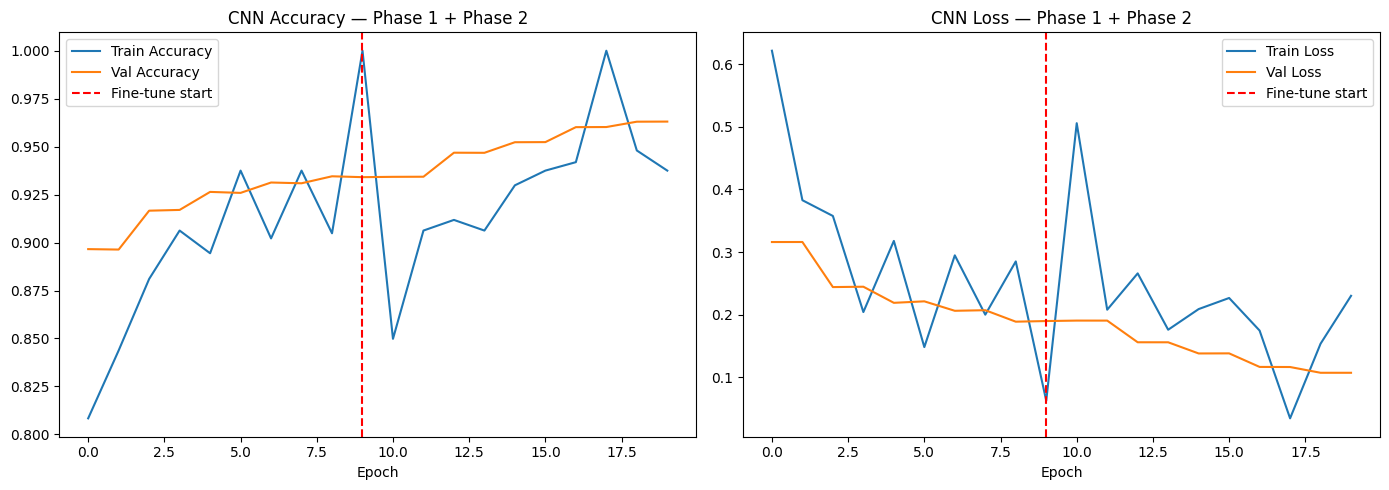

In [18]:
cnn_loss, cnn_acc = cnn_model.evaluate(valid_gen, steps=VALIDATION_STEPS)
print(f'✅ CNN Validation Accuracy: {cnn_acc*100:.2f}%')

# Combine phase 1 + phase 2 history for plotting
all_acc      = history.history['accuracy']     + history_ft.history['accuracy']
all_val_acc  = history.history['val_accuracy'] + history_ft.history['val_accuracy']
all_loss     = history.history['loss']         + history_ft.history['loss']
all_val_loss = history.history['val_loss']     + history_ft.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(all_acc,     label='Train Accuracy')
axes[0].plot(all_val_acc, label='Val Accuracy')
axes[0].axvline(x=len(history.history['accuracy'])-1,
                color='red', linestyle='--', label='Fine-tune start')
axes[0].set_title('CNN Accuracy — Phase 1 + Phase 2')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(all_loss,     label='Train Loss')
axes[1].plot(all_val_loss, label='Val Loss')
axes[1].axvline(x=len(history.history['loss'])-1,
                color='red', linestyle='--', label='Fine-tune start')
axes[1].set_title('CNN Loss — Phase 1 + Phase 2')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_training_history.png', dpi=120)
plt.show()


## FINAL COMPARISON


### Compare ALL Models

=== ALL MODELS COMPARISON ===
            Model  Test Accuracy %                                 Notes
CNN (MobileNetV2)        96.311474 Full image — Transfer Learning ✅ BEST
    Random Forest        54.176072             Color features — ensemble
     SVM (Linear)        45.372460        Color features — linear kernel
    Decision Tree        41.534989                   Color features only


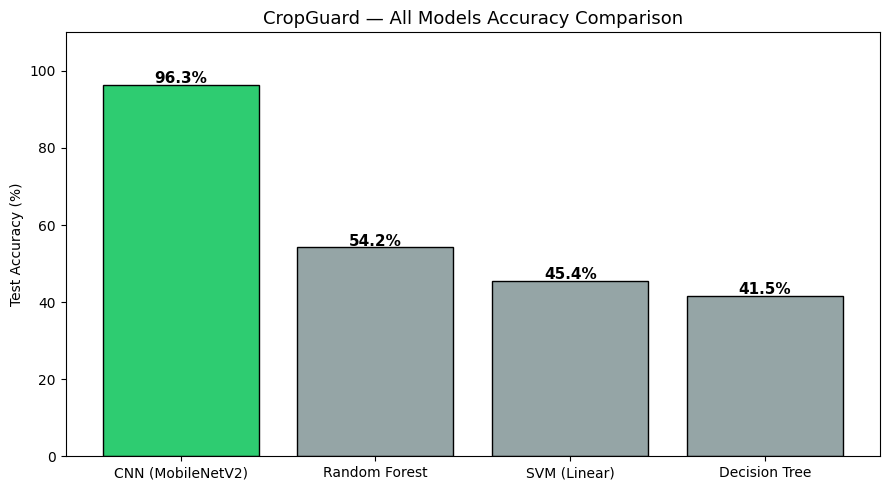

In [19]:
all_results = pd.DataFrame({
    'Model'          : ['Decision Tree', 'Random Forest', 'SVM (Linear)', 'CNN (MobileNetV2)'],
    'Test Accuracy %': [dt_test_acc*100, rf_test_acc*100, svm_test_acc*100, cnn_acc*100],
    'Notes'          : [
        'Color features only',
        'Color features — ensemble',
        'Color features — linear kernel',
        'Full image — Transfer Learning ✅ BEST'
    ]
}).sort_values('Test Accuracy %', ascending=False)

print('=== ALL MODELS COMPARISON ===')
print(all_results.to_string(index=False))

colors = ['#2ecc71' if acc == all_results['Test Accuracy %'].max() else '#95a5a6'
          for acc in all_results['Test Accuracy %']]

plt.figure(figsize=(9, 5))
bars = plt.bar(all_results['Model'], all_results['Test Accuracy %'],
               color=colors, edgecolor='black')
for bar, acc in zip(bars, all_results['Test Accuracy %']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.title('CropGuard — All Models Accuracy Comparison', fontsize=13)
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 110)
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=120)
plt.show()


### Confusion Matrix (Random Forest)

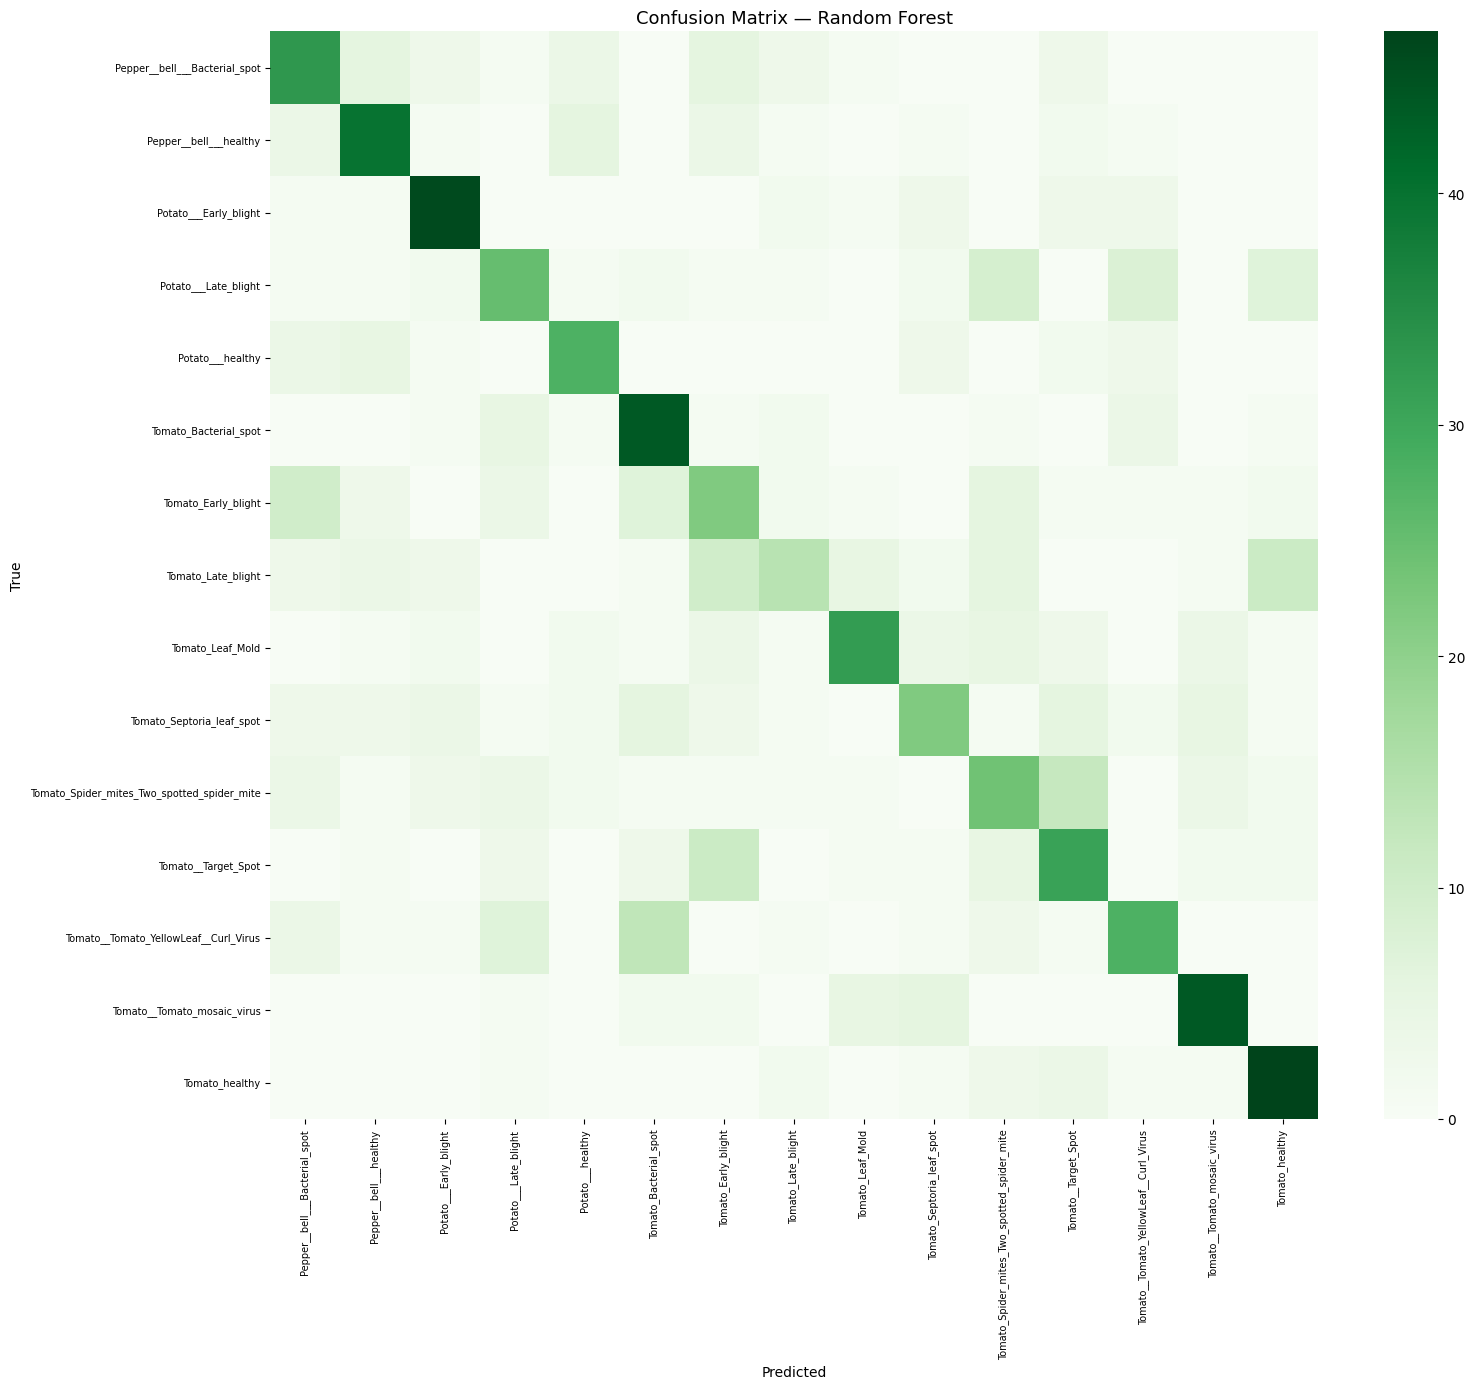


=== Classification Report — Random Forest ===
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.49      0.55      0.52        60
                     Pepper__bell___healthy       0.60      0.67      0.63        60
                      Potato___Early_blight       0.69      0.77      0.72        60
                       Potato___Late_blight       0.48      0.42      0.45        60
                           Potato___healthy       0.61      0.61      0.61        46
                      Tomato_Bacterial_spot       0.55      0.73      0.63        60
                        Tomato_Early_blight       0.34      0.37      0.35        60
                         Tomato_Late_blight       0.45      0.23      0.31        60
                           Tomato_Leaf_Mold       0.68      0.53      0.60        60
                  Tomato_Septoria_leaf_spot       0.48      0.37      0.42        60
Tomato_Spider_mit

In [20]:
y_pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Random Forest', fontsize=13)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix_RF.png', dpi=120)
plt.show()

print('\n=== Classification Report — Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


### Project Summary

In [21]:
print('=' * 60)
print('          🌿 CROPGUARD — PROJECT SUMMARY')
print('=' * 60)
print(f'  Dataset 1 (EDA + Classical) : PlantVillage')
print(f'  Dataset 2 (CNN Training)    : New Plant Diseases Dataset')
print(f'  Total Images (Dataset 1)    : {len(df)}  (capped at {MAX_PER_CLASS}/class)')
print(f'  Number of Classes           : {len(le.classes_)}')
print('-' * 60)
print(f'  Decision Tree Accuracy      : {dt_test_acc*100:.2f}%')
print(f'  Random Forest Accuracy      : {rf_test_acc*100:.2f}%')
print(f'  SVM (LinearSVC) Accuracy    : {svm_test_acc*100:.2f}%')
print(f'  CNN (MobileNetV2) Accuracy  : {cnn_acc*100:.2f}%  ← BEST')
print('-' * 60)
print('  Saved Files:')
print('    cnn_best_model.h5    → CNN model (use in Streamlit)')
print('    class_indices.json   → Class name lookup (use in Streamlit)')
print('    rf_model.pkl         → Random Forest model')
print('    svm_model.pkl        → SVM model')
print('    label_encoder.pkl    → Label encoder (classical models)')
print('=' * 60)


          🌿 CROPGUARD — PROJECT SUMMARY
  Dataset 1 (EDA + Classical) : PlantVillage
  Dataset 2 (CNN Training)    : New Plant Diseases Dataset
  Total Images (Dataset 1)    : 2952  (capped at 200/class)
  Number of Classes           : 15
------------------------------------------------------------
  Decision Tree Accuracy      : 41.53%
  Random Forest Accuracy      : 54.18%
  SVM (LinearSVC) Accuracy    : 45.37%
  CNN (MobileNetV2) Accuracy  : 96.31%  ← BEST
------------------------------------------------------------
  Saved Files:
    cnn_best_model.h5    → CNN model (use in Streamlit)
    class_indices.json   → Class name lookup (use in Streamlit)
    rf_model.pkl         → Random Forest model
    svm_model.pkl        → SVM model
    label_encoder.pkl    → Label encoder (classical models)


### Download Trained Files from Colab

In [22]:
# ✅ Download the two files you need for your Streamlit app
from google.colab import files

print("Downloading cnn_best_model.h5 ...")
files.download('cnn_best_model.h5')

print("Downloading class_indices.json ...")
files.download('class_indices.json')

print("\n✅ Download complete!")
print("Place both files in the same folder as your Streamlit app.py")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download complete!
Place both files in the same folder as your Streamlit app.py
